<a href="https://colab.research.google.com/github/yoohyunseok/Machine-Learnig-Deep-Learning/blob/main/9_2RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#순환 신경망(RNN)으로 IMDB 리뷰 분류하기

IMDB 리뷰 데이터 셋이란?
- 유명한 인터넷 영화 데이터 베이스인 imdb.com에서 수집한 리뷰를 감상 평에 따라 긍정과 부정으로 분류해 놓은 데이터셋
- 총 50,000개의 샘플로 이루어져있고 훈련 데이터와 테스트 데이터에 각각 25,000개씩 나누어져 있음

자연어 처리(Natural Language Processing):
- 컴퓨터를 사용해 인간의 언어를 처리하는 분야
- 대표적으로 음성 인식, 기계 번역, 감성 분석 등이 존재함
- IMDB 리뷰를 감상평에 따라 분류하는 작업은 감성 분석에 해당

말 뭉치(corpus): 자연어 처리 분야에서 훈련 데이터를 지칭하는 말

토큰(Token):
- 영어를 기준으로, 문장에서 모두 소문자로 바꾸고 구둣점을 삭제한 다음 공백을 기준으로 분리한 단어
- 텍스트 데이터의 경우 단어를 숫자 데이터로 바꿔서 전달한다(ex) 데이터에 등장하는 단어마다 고유한 정수 부여(이 정수는 단어의 의미나 크기와 관련이 없다)
- 특정한 용도가 정해져 있는 정수
  - 0: 패딩
  - 1: 문장의 시작
  - 2: 어휘 사전에 없는 토큰(어휘사전: 훈련 세트에서 고유한 단어를 뽑아 만든 목록)
  - 테스트 세트 안에 어휘 사전에 없는 단어가 있다면 2로 변환하여 신경망 모델에 주입한다.

In [1]:
from tensorflow.keras.datasets import imdb
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500) #어휘 사전에 500개의 단어만 넣겠다는 뜻
# imbd.load_data()는 등장 횟수가 많은 순서대로 500개의 단어를 어휘 사전에 저장
#IMDB 리뷰 데이터셋은 텐서플로ㅔ서 이미 정수로 바꾼 데이터가 포함되어있음

In [2]:
print(train_input.shape, test_input.shape) #인풋 데이터의 크기 확인
# 개별 리뷰를 담은 파이썬 리스트 객체로 이루어진 넘파이 배열

(25000,) (25000,)


In [3]:
print(len(train_input[0])) #첫 번째 리뷰의 길이 확인(218개의 토큰으로 이루어짐)

218


In [4]:
print(len(train_input[1])) #두 번째 리뷰의 길이 확인(189개의 토큰으로 이루어짐)

189


In [5]:
print(train_input[0]) #첫 번째 리뷰의 토큰
# 어휘 사전에 존재하지 않는 토큰은 2로 표시

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [6]:
print(train_target[:20]) #리뷰가 근정/부정인지 표시
# 0이 부정, 1이 긍정인 이진 분류 문제

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [7]:
# 20% 검증 세트 생성 => 훈련 세트 20,000 검증 세트 5,000
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size = 0.2, random_state = 42)

In [8]:
# 평균적인 리뷰의 길이와 가장 짧은 리뷰의 길이, 그리고 가장 긴 리뷰의 길이 확인
import numpy as np
lengths = np.array([len(x) for x in train_input])
#리뷰 길이의 평균과 중간 값 구하기
print(np.mean(lengths), np.median(lengths))
#평균과 중간값이 차이가 나는것으로 보아 이 리뷰 길이 데이터는 한쪽에 치우친 분포를 가진 가능성이 있음

239.00925 178.0


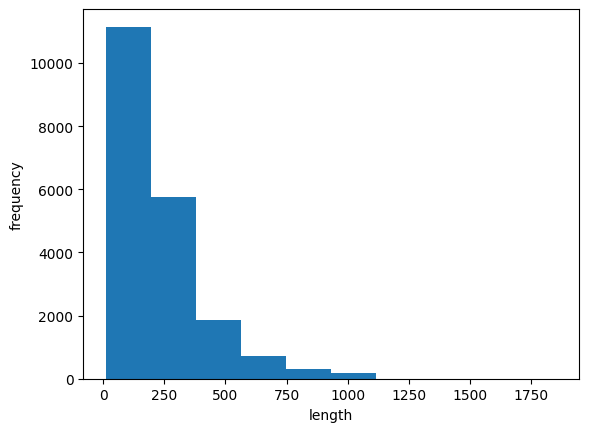

In [9]:
#진짜네?
import matplotlib.pyplot as plt
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()
# 길이가 아주 긴 소수의 리뷰가 평균을 중간값 보다 높게 만듦

**이 예제에서는 100개의 단어만 사용할 예정**

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
#시퀀스(= 하나의 샘플) 데이터의 길이를 맞춰주는 pad_sequences()
train_seq = pad_sequences(train_input, maxlen = 100) #maxlen = 100으로 지정하여 리뷰의 길이가 100보다 길면 100까지 달라내고 짧은 경우는 0으로 패딩

In [11]:
print(train_seq.shape)

(20000, 100)


In [12]:
print(train_seq[0]) #0이 없는걸 보니 이 샘플은 원래 100보다 길었구나

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [13]:
# 아까 pad_sequences()로 100개에 맞춰서 시퀀스를 잘라냈잖아? 그래서 이 샘플의 앞부분이 잘렸는지 뒷 부분이 잘렸는지 확인해볼거야
print(train_input[0][-10:]) #마지막 열개 토큰 출력
#샘플의 앞부분이 잘린거구나!

[6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


pad_sequences()
- 기본적으로 maxlen보다 긴 시퀀스의 앞 부분을 자름
- padding 매개변수는 패딩을 추가할 위치를 지정 'pre' = 시퀀스 앞부분에 패딩 추가 'post' 시퀀스 뒷 부분에 패딩 추가
- truncating 매개변수의 기본 값 = pre, 뒷 부분을 자르고 싶다면 'post'로 변경
- 일반적으로 시퀀스의 뒷 부분의 정보가 더 유용하리라 기대함
- 영화 리뷰로 예를 들자면 리뷰 끝부분에 결정적인 소감을 말할 가능성이 높다고 생각하는 것

In [14]:
print(train_seq[5]) #6 번째 시퀀스 데이터 출력
# 앞부분에 0이 있는 걸로봐서 이 시퀀스는 길이가 100보다 짧다.
# 시퀀스의 마지막에 있는 단어가 cell의 은닉 상태에 가장 큰 영향을 미치게 되므로 일반적으로 앞부분을 0으로 채운다

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


In [15]:
val_seq = pad_sequences(val_input, maxlen = 100) # 검증 세트도 100으로 패딩

# 순환 신경망 만들기

In [16]:
from tensorflow import keras
model = keras.Sequential()
model.add(keras.layers.SimpleRNN(8, input_shape = (100, 500))) #인풋 셰잎이 100, 500인 이유..샘플의 길이를 100으로 설정했으니까 100, 500은....
# 원-핫 인코딩 방식으로 표현하려면 배열의 길이가 500이어야한다
# 만약 토큰 10을 원 핫 인코딩으로 표현할려면 열한 번째 원소만 1이고 나머지는 다 0이어야 한다.
# imdb.load_data() 함수에서 500개의 단어만 사용하도록 지정했기 때문에 배열의 길이가 500이어야한다.
# 이를 통해 아무 의미 없는 정수 사이의 대소 관계로 인한 문제를 해결한다.
model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# keras.utils 패키지 아래에 있는 to_categorical() 함수 = 정수 배열을 입력하면 원-핫 인코딩 배열로 반환해줌
train_oh = keras.utils.to_categorical(train_seq)

In [18]:
print(train_oh.shape)

(20000, 100, 500)


In [19]:
print(train_oh[0][0][:12]) #처음 12개의 원소를 출력
# 11번째 원소가 1임 = 토큰 10을 의미

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [20]:
#다른 원소들은 다 0인지 확인
print(np.sum(train_oh[0][0]))

1.0


In [21]:
val_oh = keras.utils.to_categorical(val_seq)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

# RNN 훈련하기

In [23]:
'''
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4) #rmsprop 옵티마이저 학습률 0.0001로 조정
#모델 컴파일
model.compile(optimizer=rmsprop, loss = 'binary_crossentropy', metrics = ['accuracy']) # 옵티마이저 = romprop, 손실함수 = binary_crossentropy(이진분류니까)
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.h5', save_best_only = True) #최선의 모델을 best-simplernn-model.h5 파일에 저장
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3, restore_best_weights=True) #모델이 3번동안 개선이 안되면 조기 종료 후 최선의 모델로 복구
history = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])
'''

"\nrmsprop = keras.optimizers.RMSprop(learning_rate=1e-4) #rmsprop 옵티마이저 학습률 0.0001로 조정\n#모델 컴파일\nmodel.compile(optimizer=rmsprop, loss = 'binary_crossentropy', metrics = ['accuracy']) # 옵티마이저 = romprop, 손실함수 = binary_crossentropy(이진분류니까)\ncheckpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.h5', save_best_only = True) #최선의 모델을 best-simplernn-model.h5 파일에 저장\nearly_stopping_cb = keras.callbacks.EarlyStopping(patience = 3, restore_best_weights=True) #모델이 3번동안 개선이 안되면 조기 종료 후 최선의 모델로 복구\nhistory = model.fit(train_oh, train_target, epochs=100, batch_size=64, validation_data=(val_oh, val_target), callbacks=[checkpoint_cb, early_stopping_cb])\n"

**원-핫 인코딩을 사용하면 여기서는 토큰 1개를 500차원으로 늘렸기 때문에 용량이 대략 500배가 커진다. 그래서 코드 실행 중 세션이 다운되는 문제가 발생....**

# 단어 임베딩(word embedding)을 사용하기

- 각 단어를 고정된 크기의 실수 벡터로 바꾸어주는 방식
- 원-핫 인코딩된 벡터보다 훨씬 의미 있는 값으로 채워지기 때문에 더 좋은 성능을 내는 경우가 많음
- Embedding 클래스 사용
- 처음에는 모든 벡터가 랜덤하게 초기화되지만 훈련을 통해 데이터에서 좋은 단어 임베딩을 학습
- 입력을 정수 데이터로 받는다는 장점이 있음 => 메모리 효율 업!!``

In [24]:
model2 = keras.Sequential()
model2.add(keras.layers.Embedding(500, 16, input_length = 100))
# Embedding 클래스의 첫 번째 매개변수: 어휘 사전의 크기
# 두 번째 매개변수: 임베딩 벡터의 크기
# 세 번째 매개변수: 시퀀스의 길이
model2.add(keras.layers.SimpleRNN(8))
model2.add(keras.layers.Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model2.build(input_shape=(None, 100)) # 명시적으로 모델 빌드
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

### `model2.summary()` 예상 출력 설명:

`model2`는 다음과 같이 구성되어 있습니다:

1.  **`Embedding` 레이어 (Input -> Hidden Features)**:
    *   `keras.layers.Embedding(500, 16, input_length = 100)`:
        *   `500`: 어휘 사전의 크기 (총 500개의 고유 단어를 사용).
        *   `16`: 각 단어를 16차원의 벡터로 임베딩 (단어 임베딩 벡터의 크기).
        *   `input_length = 100`: 입력 시퀀스의 길이 (각 리뷰는 100개의 단어로 구성).
    *   **`Output Shape`**: `(None, 100, 16)`
        *   `None`: 배치 크기를 의미합니다. (몇 개의 샘플이든 상관없이 처리 가능)
        *   `100`: 시퀀스 길이입니다 (각 리뷰에 100개의 단어가 있음).
        *   `16`: 각 단어의 임베딩 벡터 크기입니다.
    *   **`Param #`**: `8000`
        *   `어휘 사전 크기 * 임베딩 벡터 크기 = 500 * 16 = 8000`
        *   이는 500개의 단어 각각에 대한 16차원 임베딩 벡터를 저장하는 가중치입니다.

2.  **`SimpleRNN` 레이어 (Recurrent Layer)**:
    *   `keras.layers.SimpleRNN(8)`:
        *   `8`: RNN 셀의 유닛(뉴런) 수입니다.
    *   **`Output Shape`**: `(None, 8)`
        *   `SimpleRNN` 레이어는 기본적으로 시퀀스의 마지막 타임스텝의 은닉 상태만 출력합니다. 따라서 각 샘플당 8차원의 벡터를 반환합니다.
    *   **`Param #`**: `200`
        *   `(입력 특성 수 * RNN 유닛 수) + (RNN 유닛 수 * RNN 유닛 수) + RNN 유닛 수`
        *   `입력 특성 수`는 이전 레이어(`Embedding`)의 `Output Shape`에서 마지막 차원인 16입니다.
        *   `16 (입력) * 8 (유닛) + 8 (유닛) * 8 (재귀) + 8 (바이어스) = 128 + 64 + 8 = 200`

3.  **`Dense` 레이어 (Output Layer)**:
    *   `keras.layers.Dense(1, activation = 'sigmoid')`:
        *   `1`: 출력 뉴런의 수입니다. (이진 분류이므로 1개)
        *   `'sigmoid'`: 시그모이드 활성화 함수를 사용하여 0과 1 사이의 확률을 출력합니다.
    *   **`Output Shape`**: `(None, 1)`
        *   각 샘플에 대해 1개의 출력 값을 반환합니다.
    *   **`Param #`**: `9`
        *   `(입력 특성 수 * 출력 뉴런 수) + 출력 뉴런 수`
        *   `입력 특성 수`는 이전 레이어(`SimpleRNN`)의 `Output Shape`에서 마지막 차원인 8입니다.
        *   `8 (입력) * 1 (출력) + 1 (바이어스) = 8 + 1 = 9`

**`Total params`**: `8000 + 200 + 9 = 8209`

이러한 정보가 `model2.summary()`를 실행하면 정상적으로 표시될 것입니다.

In [27]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4) #rmsprop 옵티마이저 학습률 0.0001로 조정
#모델 컴파일
model2.compile(optimizer=rmsprop, loss = 'binary_crossentropy', metrics = ['accuracy']) # 옵티마이저 = romprop, 손실함수 = binary_crossentropy(이진분류니까)
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.h5', save_best_only = True) #최선의 모델을 best-simplernn-model.h5 파일에 저장
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 3, restore_best_weights=True) #모델이 3번동안 개선이 안되면 조기 종료 후 최선의 모델로 복구
history = model2.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4974 - loss: 0.6965

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5011 - loss: 0.6949 - val_accuracy: 0.5082 - val_loss: 0.6926
Epoch 2/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5339 - loss: 0.6905

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5371 - loss: 0.6898 - val_accuracy: 0.5320 - val_loss: 0.6895
Epoch 3/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5609 - loss: 0.6861

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.5651 - loss: 0.6851 - val_accuracy: 0.5346 - val_loss: 0.6870
Epoch 4/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5844 - loss: 0.6791

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6054 - loss: 0.6739 - val_accuracy: 0.6530 - val_loss: 0.6607
Epoch 5/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6778 - loss: 0.6467

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8083 - loss: 0.4441 - val_accuracy: 0.7860 - val_loss: 0.4711
Epoch 17/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8095 - loss: 0.4387

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8077 - loss: 0.4406 - val_accuracy: 0.7846 - val_loss: 0.4687
Epoch 18/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8111 - loss: 0.4354

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8104 - loss: 0.4367 - val_accuracy: 0.7852 - val_loss: 0.4645
Epoch 19/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8131 - loss: 0.4321

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8106 - loss: 0.4344 - val_accuracy: 0.7876 - val_loss: 0.4628
Epoch 20/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8159 - loss: 0.4278

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8135 - loss: 0.4300 - val_accuracy: 0.7878 - val_loss: 0.4595
Epoch 21/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8153 - loss: 0.4281 - val_accuracy: 0.7880 - val_loss: 0.4614
Epoch 22/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8163 - loss: 0.4260 - val_accuracy: 0.7908 - val_loss: 0.4611
Epoch 23/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8169 - loss: 0.4233 - val_accuracy: 0.7736 - val_loss: 0.4860


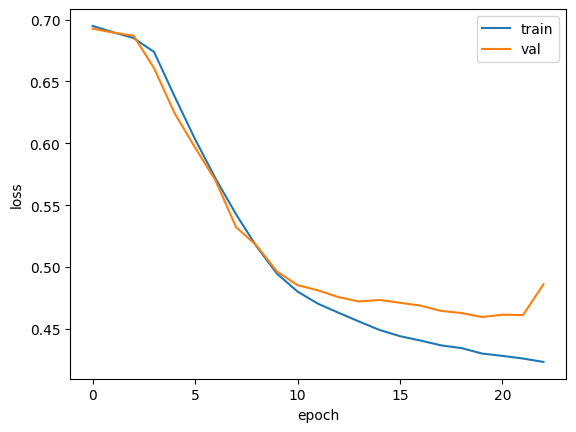

In [28]:
# 훈련 손실과 검증 손실 확인
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()